In [1]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dotenv import load_dotenv
import datetime
import os
import utils
import random

In [2]:
load_dotenv()
# f"postgres+psycopg2://{[user]}:{[pass]}@{[host}:{[port]}/{[dbname]}"
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

In [3]:
start_time='08:00:00'
end_time='09:30:00'
query_min = "SELECT * FROM gold.active_1min WHERE bar_time BETWEEN %(start)s AND %(end)s ORDER BY bar_date, bar_time"
df_min = pd.read_sql(query_min,engine, params={"start": start_time, "end": end_time})

In [4]:
df_swings= utils.get_swings(df_min)
df_swings['profit'] = np.where(
    df_swings['trend']=='UP', 
    abs(df_swings['open']-df_swings['high']), 
    abs(df_swings['open']-df_swings['low'])
)
df_swings = utils.add_winsorized_col(df_swings,'profit')

In [9]:
chart_day= None
def chart_visualize(date=None):
    global chart_day
    chart_day = df_min['bar_date'].iloc[random.randint(0,len(df_min))] if date is None else date
    print(chart_day)
    utils.display_market_chart(df_min,chart_day)
    utils.display_market_chart(df_swings,chart_day,date_col='date',time_col='time_start')

2025-07-15


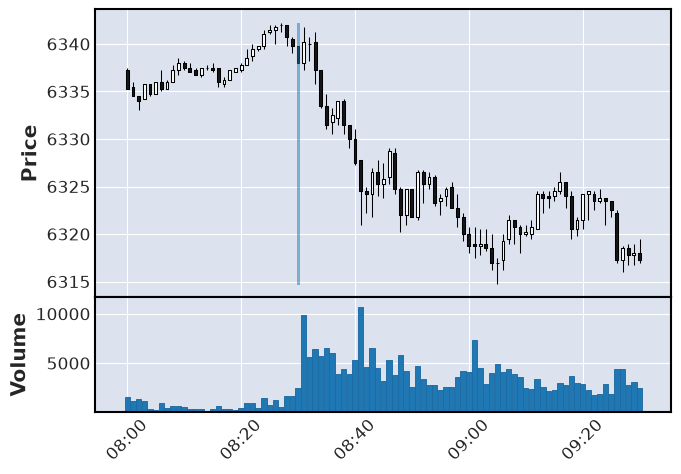

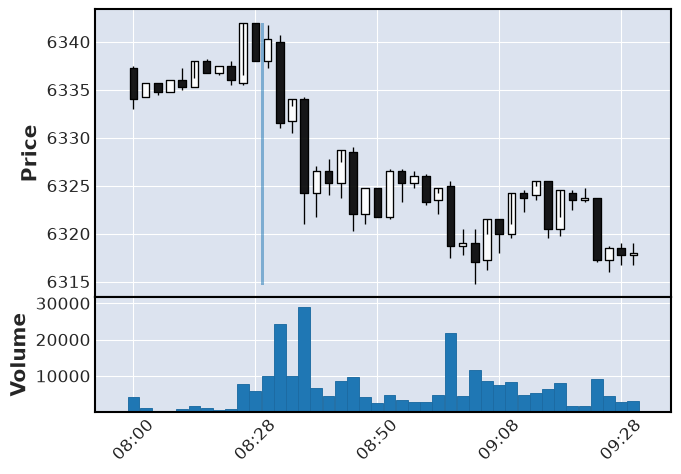

In [10]:
#2025-01-28
date = datetime.date(2025,1,28)
chart_visualize()

In [7]:
df_swings[df_swings['date']==chart_day]

,date,time_start,time_end,high,open,close,low,volume,following_price_movement,fighting_price_movememnt,trend,bucket_30min,bucket_15min,bucket_5min,profit,profit_winsorized
938,2025-01-28,08:00:00,08:00:00,6055.25,6054.50,6055.00,6054.25,358.0,0.75,0.25,UP,08:00:00,08:00:00,08:00:00,0.75,0.75
939,2025-01-28,08:01:00,08:02:00,6055.00,6054.75,6053.50,6053.25,644.0,2.00,0.25,DOWN,08:00:00,08:00:00,08:00:00,1.50,1.50
940,2025-01-28,08:03:00,08:03:00,6057.75,6053.75,6057.75,6053.75,838.0,4.00,0.00,UP,08:00:00,08:00:00,08:00:00,4.00,4.00
941,2025-01-28,08:04:00,08:10:00,6057.75,6057.50,6052.25,6052.00,2732.0,8.25,3.25,DOWN,08:00:00,08:00:00,08:00:00,5.50,5.50
942,2025-01-28,08:11:00,08:11:00,6053.75,6052.50,6053.50,6052.00,518.0,1.25,0.50,UP,08:00:00,08:00:00,08:10:00,1.25,1.25
943,2025-01-28,08:12:00,08:12:00,6053.75,6053.50,6052.75,6052.75,421.0,0.75,0.25,DOWN,08:00:00,08:00:00,08:10:00,0.75,0.75
944,2025-01-28,08:13:00,08:14:00,6053.50,6052.50,6053.50,6052.00,632.0,1.75,1.00,UP,08:00:00,08:00:00,08:10:00,1.00,1.00
945,2025-01-28,08:15:00,08:17:00,6054.75,6053.75,6051.75,6051.00,1995.0,3.00,1.75,DOWN,08:00:00,08:15:00,08:15:00,2.75,2.75
946,2025-01-28,08:18:00,08:18:00,6053.75,6052.00,6052.75,6052.00,693.0,1.75,0.00,UP,08:00:00,08:15:00,08:15:00,1.75,1.75
947,2025-01-28,08:19:00,08:20:00,6053.50,6052.75,6052.50,6052.25,641.0,0.50,1.25,DOWN,08:00:00,08:15:00,08:15:00,0.50,0.50
